<a href="https://colab.research.google.com/github/leandrofigueiraalmeida/Challenge-Telecom-X-Alura/blob/main/TelecomX_BR_LeandroFigueiraAlmeida_git.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Leandro Figueira de Almeida

📡 TelecomX - Análise de Evasão de Clientes (Churn)

## 📄 Relatório Final

### Introdução
Este notebook tem como objetivo realizar uma análise completa dos dados de clientes da TelecomX, com foco na **evasão de clientes (Churn)**. A evasão de clientes é um dos maiores desafios enfrentados por empresas de telecomunicações, pois a perda de clientes impacta diretamente a receita e a sustentabilidade do negócio.

Através de um processo de **ETL (Extração, Transformação e Carga)**, iremos:
- Extrair os dados de uma fonte JSON
- Limpar e tratar inconsistências
- Realizar análises exploratórias com visualizações
- Identificar padrões e insights para reduzir a evasão

---
# 📌 1. Extração dos Dados

In [7]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import requests
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [8]:
# Carregar os dados diretamente da API (URL do JSON)
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

response = requests.get(url)
dados_json = response.json()

print(f'Total de registros carregados: {len(dados_json)}')
print(f'Tipo dos dados: {type(dados_json)}')

Total de registros carregados: 7267
Tipo dos dados: <class 'list'>


In [9]:
# Visualizar a estrutura de um registro
print(json.dumps(dados_json[0], indent=2, ensure_ascii=False))

{
  "customerID": "0002-ORFBO",
  "Churn": "No",
  "customer": {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "Yes",
    "tenure": 9
  },
  "phone": {
    "PhoneService": "Yes",
    "MultipleLines": "No"
  },
  "internet": {
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "Yes",
    "StreamingTV": "Yes",
    "StreamingMovies": "No"
  },
  "account": {
    "Contract": "One year",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Mailed check",
    "Charges": {
      "Monthly": 65.6,
      "Total": "593.3"
    }
  }
}


In [10]:
# Converter JSON para DataFrame usando json_normalize para achatar a estrutura aninhada
df = pd.json_normalize(dados_json)

print(f'Dimensões do DataFrame: {df.shape}')
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
df.head()

Dimensões do DataFrame: (7267, 21)
Linhas: 7267 | Colunas: 21


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


---
# 🔧 2. Transformação dos Dados

## 2.1 Conhecendo o Dataset

### Dicionário de Dados
| Coluna | Descrição |
|--------|----------|
| customerID | Número de identificação único de cada cliente |
| Churn | Se o cliente deixou ou não a empresa |
| gender | Gênero (masculino e feminino) |
| SeniorCitizen | Se o cliente tem idade ≥ 65 anos |
| Partner | Se o cliente possui parceiro(a) |
| Dependents | Se o cliente possui dependentes |
| tenure | Meses de contrato do cliente |
| PhoneService | Assinatura de serviço telefônico |
| MultipleLines | Assinatura de mais de uma linha |
| InternetService | Assinatura de provedor internet |
| OnlineSecurity | Assinatura adicional de segurança online |
| OnlineBackup | Assinatura adicional de backup online |
| DeviceProtection | Assinatura adicional de proteção no dispositivo |
| TechSupport | Assinatura adicional de suporte técnico |
| StreamingTV | Assinatura de TV a cabo |
| StreamingMovies | Assinatura de streaming de filmes |
| Contract | Tipo de contrato |
| PaperlessBilling | Fatura online |
| PaymentMethod | Forma de pagamento |
| Charges.Monthly | Total mensal dos serviços |
| Charges.Total | Total gasto pelo cliente |

In [11]:
# Explorar as colunas e tipos de dados
print('=== Informações do Dataset ===')
df.info()

=== Informações do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupp

In [12]:
# Renomear colunas para um padrão mais legível
df.columns = [col.replace('customer.', '').replace('phone.', '').replace('internet.', '').replace('account.', '').replace('Charges.', 'Cobr_') for col in df.columns]

print('Colunas renomeadas:')
print(df.columns.tolist())

Colunas renomeadas:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Cobr_Monthly', 'Cobr_Total']


In [13]:
# Verificar as primeiras linhas após renomeação
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Cobr_Monthly,Cobr_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## 2.2 Verificando Inconsistências nos Dados

In [14]:
# Verificar valores nulos
print('=== Valores Nulos ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Nenhum valor nulo encontrado!')
print(f'\nTotal de valores nulos: {nulos.sum()}')

=== Valores Nulos ===
Nenhum valor nulo encontrado!

Total de valores nulos: 0


In [15]:
# Verificar duplicados
duplicados = df.duplicated().sum()
print(f'=== Registros Duplicados ===')
print(f'Total de duplicados: {duplicados}')

# Verificar duplicados por customerID
dup_id = df['customerID'].duplicated().sum()
print(f'IDs de clientes duplicados: {dup_id}')

=== Registros Duplicados ===
Total de duplicados: 0
IDs de clientes duplicados: 0


In [16]:
# Verificar tipos de dados e possíveis inconsistências
print('=== Tipos de Dados ===')
print(df.dtypes)
print('\n=== Verificando coluna Cobr_Total ===')
print(f'Tipo: {df["Cobr_Total"].dtype}')

# Verificar se Cobr_Total tem valores não numéricos
if df['Cobr_Total'].dtype == 'object':
    nao_numerico = pd.to_numeric(df['Cobr_Total'], errors='coerce').isna().sum()
    print(f'Valores não numéricos em Cobr_Total: {nao_numerico}')

=== Tipos de Dados ===
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Cobr_Monthly        float64
Cobr_Total           object
dtype: object

=== Verificando coluna Cobr_Total ===
Tipo: object
Valores não numéricos em Cobr_Total: 11


In [17]:
# Verificar valores únicos das variáveis categóricas
print('=== Valores Únicos por Coluna Categórica ===')
for col in df.select_dtypes(include='object').columns:
    print(f'\n{col}: {df[col].unique()}')

=== Valores Únicos por Coluna Categórica ===

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Churn: ['No' 'Yes' '']

gender: ['Female' 'Male']

Partner: ['Yes' 'No']

Dependents: ['Yes' 'No']

PhoneService: ['Yes' 'No']

MultipleLines: ['No' 'Yes' 'No phone service']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['Yes' 'No' 'No internet service']

StreamingTV: ['Yes' 'No' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['One year' 'Month-to-month' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

Cobr_Total: ['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']


## 2.3 Tratando as Inconsistências

In [18]:
# Converter Cobr_Total para numérico
df['Cobr_Total'] = pd.to_numeric(df['Cobr_Total'], errors='coerce')

# Verificar se a conversão gerou nulos
nulos_total = df['Cobr_Total'].isna().sum()
print(f'Valores nulos em Cobr_Total após conversão: {nulos_total}')

# Preencher nulos com 0 (clientes novos provavelmente)
if nulos_total > 0:
    df['Cobr_Total'].fillna(0, inplace=True)
    print(f'Valores nulos preenchidos com 0.')

Valores nulos em Cobr_Total após conversão: 11
Valores nulos preenchidos com 0.


In [19]:
# Remover duplicados se existirem
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicados removidos. Novo shape: {df.shape}')
else:
    print('Sem duplicados para remover.')

# Verificar valores nulos restantes
print(f'\nValores nulos restantes: {df.isnull().sum().sum()}')

Sem duplicados para remover.

Valores nulos restantes: 0


## 2.4 Criação da Coluna de Contas Diárias

In [20]:
# Criar coluna Contas_Diarias a partir do faturamento mensal
df['Contas_Diarias'] = round(df['Cobr_Monthly'] / 30, 2)

print('=== Coluna Contas_Diarias criada ===')
print(df[['Cobr_Monthly', 'Contas_Diarias']].head(10))
print(f'\nMédia diária: R$ {df["Contas_Diarias"].mean():.2f}')

=== Coluna Contas_Diarias criada ===
   Cobr_Monthly  Contas_Diarias
0         65.60            2.19
1         59.90            2.00
2         73.90            2.46
3         98.00            3.27
4         83.90            2.80
5         69.40            2.31
6        109.70            3.66
7         84.65            2.82
8         48.20            1.61
9         90.45            3.02

Média diária: R$ 2.16


## 2.5 Padronização e Transformação de Dados

In [21]:
# Tradução e mapeamento de valores binários
mapa_sim_nao = {'Yes': 1, 'No': 0}

colunas_binarias = ['Churn', 'Partner', 'Dependents', 'PhoneService',
                    'PaperlessBilling']

for col in colunas_binarias:
    if col in df.columns:
        df[col] = df[col].map(mapa_sim_nao)

print('Colunas binárias convertidas para 0/1:')
print(df[colunas_binarias].head())

Colunas binárias convertidas para 0/1:
   Churn  Partner  Dependents  PhoneService  PaperlessBilling
0    0.0        1           1             1                 1
1    0.0        0           0             1                 0
2    1.0        0           0             1                 1
3    1.0        1           0             1                 1
4    1.0        1           0             1                 1


In [22]:
# Traduzir colunas com 'Yes', 'No', 'No internet service', 'No phone service'
mapa_servicos = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}

colunas_servicos = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in colunas_servicos:
    if col in df.columns:
        df[col] = df[col].map(mapa_servicos)

print('Colunas de serviços convertidas para 0/1:')
print(df[colunas_servicos].head())

Colunas de serviços convertidas para 0/1:
   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0              0               0             1                 0            1   
1              1               0             0                 0            0   
2              0               0             0                 1            0   
3              0               0             1                 1            0   
4              0               0             0                 0            1   

   StreamingTV  StreamingMovies  
0            1                0  
1            0                1  
2            0                0  
3            1                1  
4            1                0  


In [23]:
# Traduzir a coluna gender
df['gender'] = df['gender'].map({'Male': 'Masculino', 'Female': 'Feminino'})

# Traduzir a coluna Contract
df['Contract'] = df['Contract'].map({
    'Month-to-month': 'Mensal',
    'One year': 'Um ano',
    'Two year': 'Dois anos'
})

# Traduzir PaymentMethod
df['PaymentMethod'] = df['PaymentMethod'].map({
    'Electronic check': 'Cheque eletrônico',
    'Mailed check': 'Cheque por correio',
    'Bank transfer (automatic)': 'Transf. bancária (auto)',
    'Credit card (automatic)': 'Cartão de crédito (auto)'
})

# Traduzir InternetService
df['InternetService'] = df['InternetService'].map({
    'DSL': 'DSL',
    'Fiber optic': 'Fibra óptica',
    'No': 'Sem internet'
})

print('=== Dados traduzidos ===')
df[['gender', 'Contract', 'PaymentMethod', 'InternetService']].head()

=== Dados traduzidos ===


,gender,Contract,PaymentMethod,InternetService
0,Feminino,Um ano,Cheque por correio,DSL
1,Masculino,Mensal,Cheque por correio,DSL
2,Masculino,Mensal,Cheque eletrônico,Fibra óptica
3,Masculino,Mensal,Cheque eletrônico,Fibra óptica
4,Feminino,Mensal,Cheque por correio,Fibra óptica


In [24]:
# Renomear colunas para português
df.rename(columns={
    'customerID': 'ID_Cliente',
    'Churn': 'Evasao',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Parceiro',
    'Dependents': 'Dependentes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servico_Telefone',
    'MultipleLines': 'Multiplas_Linhas',
    'InternetService': 'Servico_Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'TV_Streaming',
    'StreamingMovies': 'Filmes_Streaming',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Metodo_Pagamento',
    'Cobr_Monthly': 'Cobr_Mensal',
    'Cobr_Total': 'Cobr_Total'
}, inplace=True)

print('=== Colunas finais ===')
print(df.columns.tolist())
df.head()

=== Colunas finais ===
['ID_Cliente', 'Evasao', 'Genero', 'Idoso', 'Parceiro', 'Dependentes', 'Meses_Contrato', 'Servico_Telefone', 'Multiplas_Linhas', 'Servico_Internet', 'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'TV_Streaming', 'Filmes_Streaming', 'Contrato', 'Fatura_Digital', 'Metodo_Pagamento', 'Cobr_Mensal', 'Cobr_Total', 'Contas_Diarias']


,ID_Cliente,Evasao,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,TV_Streaming,Filmes_Streaming,Contrato,Fatura_Digital,Metodo_Pagamento,Cobr_Mensal,Cobr_Total,Contas_Diarias
0,0002-ORFBO,0.0,Feminino,0,1,1,9,1,0,DSL,...,0,1,1,0,Um ano,1,Cheque por correio,65.6,593.30,2.19
1,0003-MKNFE,0.0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensal,0,Cheque por correio,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Masculino,0,0,0,4,1,0,Fibra óptica,...,1,0,0,0,Mensal,1,Cheque eletrônico,73.9,280.85,2.46
3,0011-IGKFF,1.0,Masculino,1,1,0,13,1,0,Fibra óptica,...,1,0,1,1,Mensal,1,Cheque eletrônico,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Feminino,1,1,0,3,1,0,Fibra óptica,...,0,1,1,0,Mensal,1,Cheque por correio,83.9,267.40,2.80


In [25]:
# Criar coluna com total de serviços contratados
colunas_servicos_pt = ['Servico_Telefone', 'Multiplas_Linhas', 'Seguranca_Online',
                       'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico',
                       'TV_Streaming', 'Filmes_Streaming']

df['Total_Servicos'] = df[colunas_servicos_pt].sum(axis=1)

print(f'\nMédia de serviços contratados: {df["Total_Servicos"].mean():.1f}')
print(df[['ID_Cliente', 'Total_Servicos']].head())


Média de serviços contratados: 3.4
   ID_Cliente  Total_Servicos
0  0002-ORFBO               4
1  0003-MKNFE               3
2  0004-TLHLJ               2
3  0011-IGKFF               5
4  0013-EXCHZ               3


In [26]:
# Verificação final do dataset transformado
print('=== Dataset Final ===')
print(f'Shape: {df.shape}')
print(f'Valores nulos: {df.isnull().sum().sum()}')
df.info()

=== Dataset Final ===
Shape: (7267, 23)
Valores nulos: 224
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Cliente            7267 non-null   object 
 1   Evasao                7043 non-null   float64
 2   Genero                7267 non-null   object 
 3   Idoso                 7267 non-null   int64  
 4   Parceiro              7267 non-null   int64  
 5   Dependentes           7267 non-null   int64  
 6   Meses_Contrato        7267 non-null   int64  
 7   Servico_Telefone      7267 non-null   int64  
 8   Multiplas_Linhas      7267 non-null   int64  
 9   Servico_Internet      7267 non-null   object 
 10  Seguranca_Online      7267 non-null   int64  
 11  Backup_Online         7267 non-null   int64  
 12  Protecao_Dispositivo  7267 non-null   int64  
 13  Suporte_Tecnico       7267 non-null   int64  
 14  TV_Streaming 

In [29]:
# Conversão datast para .csv
df.to_csv('TelecomX.csv', index=False)

# Salvar arquico no Colab
from google.colab import files

files.download('TelecomX.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# 📊 3. Carga e Análise

## 3.1 Análise Descritiva

In [ ]:
# Estatísticas descritivas das variáveis numéricas
print('=== Estatísticas Descritivas ===')
df.describe().round(2)

=== Estatísticas Descritivas ===


,Evasao,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,TV_Streaming,Filmes_Streaming,Fatura_Digital,Cobr_Mensal,Cobr_Total,Contas_Diarias,Total_Servicos
count,7043.00,7267.00,7267.00,7267.00,7267.00,7267.0,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00
mean,0.27,0.16,0.48,0.30,32.35,0.9,0.42,0.29,0.34,0.34,0.29,0.38,0.39,0.59,64.72,2277.18,2.16,3.36
std,0.44,0.37,0.50,0.46,24.57,0.3,0.49,0.45,0.48,0.47,0.45,0.49,0.49,0.49,30.13,2268.65,1.00,2.06
min,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.25,0.00,0.61,0.00
25%,0.00,0.00,0.00,0.00,9.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,35.42,396.20,1.18,1.00
50%,0.00,0.00,0.00,0.00,29.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,70.30,1389.20,2.34,3.00
75%,1.00,0.00,1.00,1.00,55.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,89.88,3778.52,3.00,5.00
max,1.00,1.00,1.00,1.00,72.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,118.75,8684.80,3.96,8.00


In [ ]:
# Comparação de métricas entre clientes que evadiram e os que ficaram
print('=== Métricas por Status de Evasão ===')
metricas = df.groupby('Evasao')[['Meses_Contrato', 'Cobr_Mensal', 'Cobr_Total', 'Contas_Diarias', 'Total_Servicos']].mean().round(2)
metricas.index = ['Ficou', 'Evadiu']
metricas

=== Métricas por Status de Evasão ===


,Meses_Contrato,Cobr_Mensal,Cobr_Total,Contas_Diarias,Total_Servicos
Ficou,37.57,61.27,2549.91,2.04,3.45
Evadiu,17.98,74.44,1531.80,2.48,3.13


## 3.2 Distribuição da Evasão

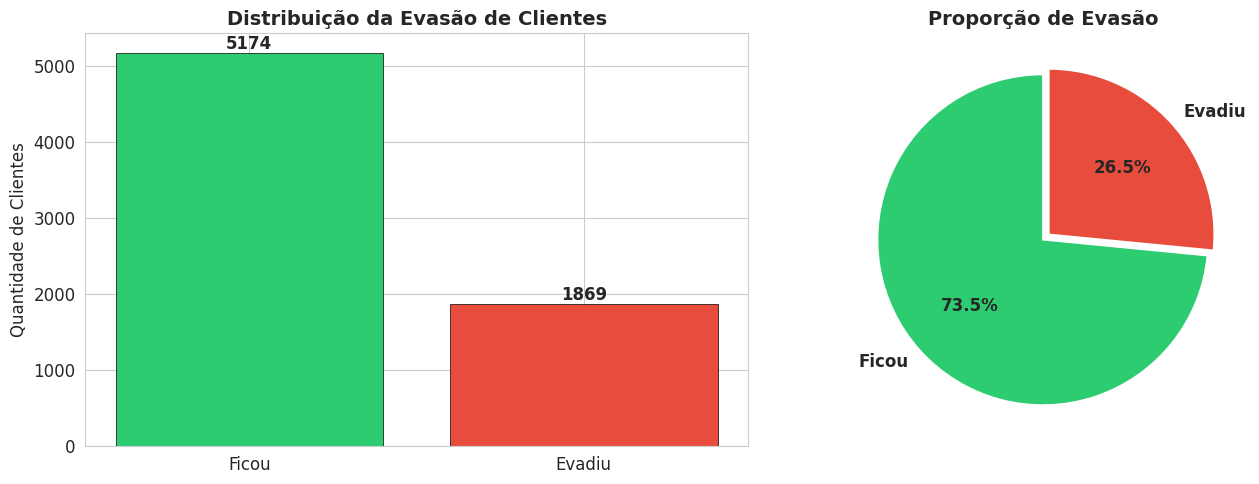


Taxa de Evasão: 25.7%


In [ ]:
# Gráfico de distribuição da evasão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem
contagem_evasao = df['Evasao'].value_counts()
contagem_evasao.index = ['Ficou', 'Evadiu']

cores = ['#2ecc71', '#e74c3c']

# Gráfico de barras
axes[0].bar(contagem_evasao.index, contagem_evasao.values, color=cores, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribuição da Evasão de Clientes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Quantidade de Clientes')
for i, v in enumerate(contagem_evasao.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)

# Gráfico de pizza
axes[1].pie(contagem_evasao.values, labels=contagem_evasao.index, autopct='%1.1f%%',
            colors=cores, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proporção de Evasão', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nTaxa de Evasão: {(df["Evasao"].sum() / len(df) * 100):.1f}%')

## 3.3 Contagem de Evasão por Variáveis Categóricas

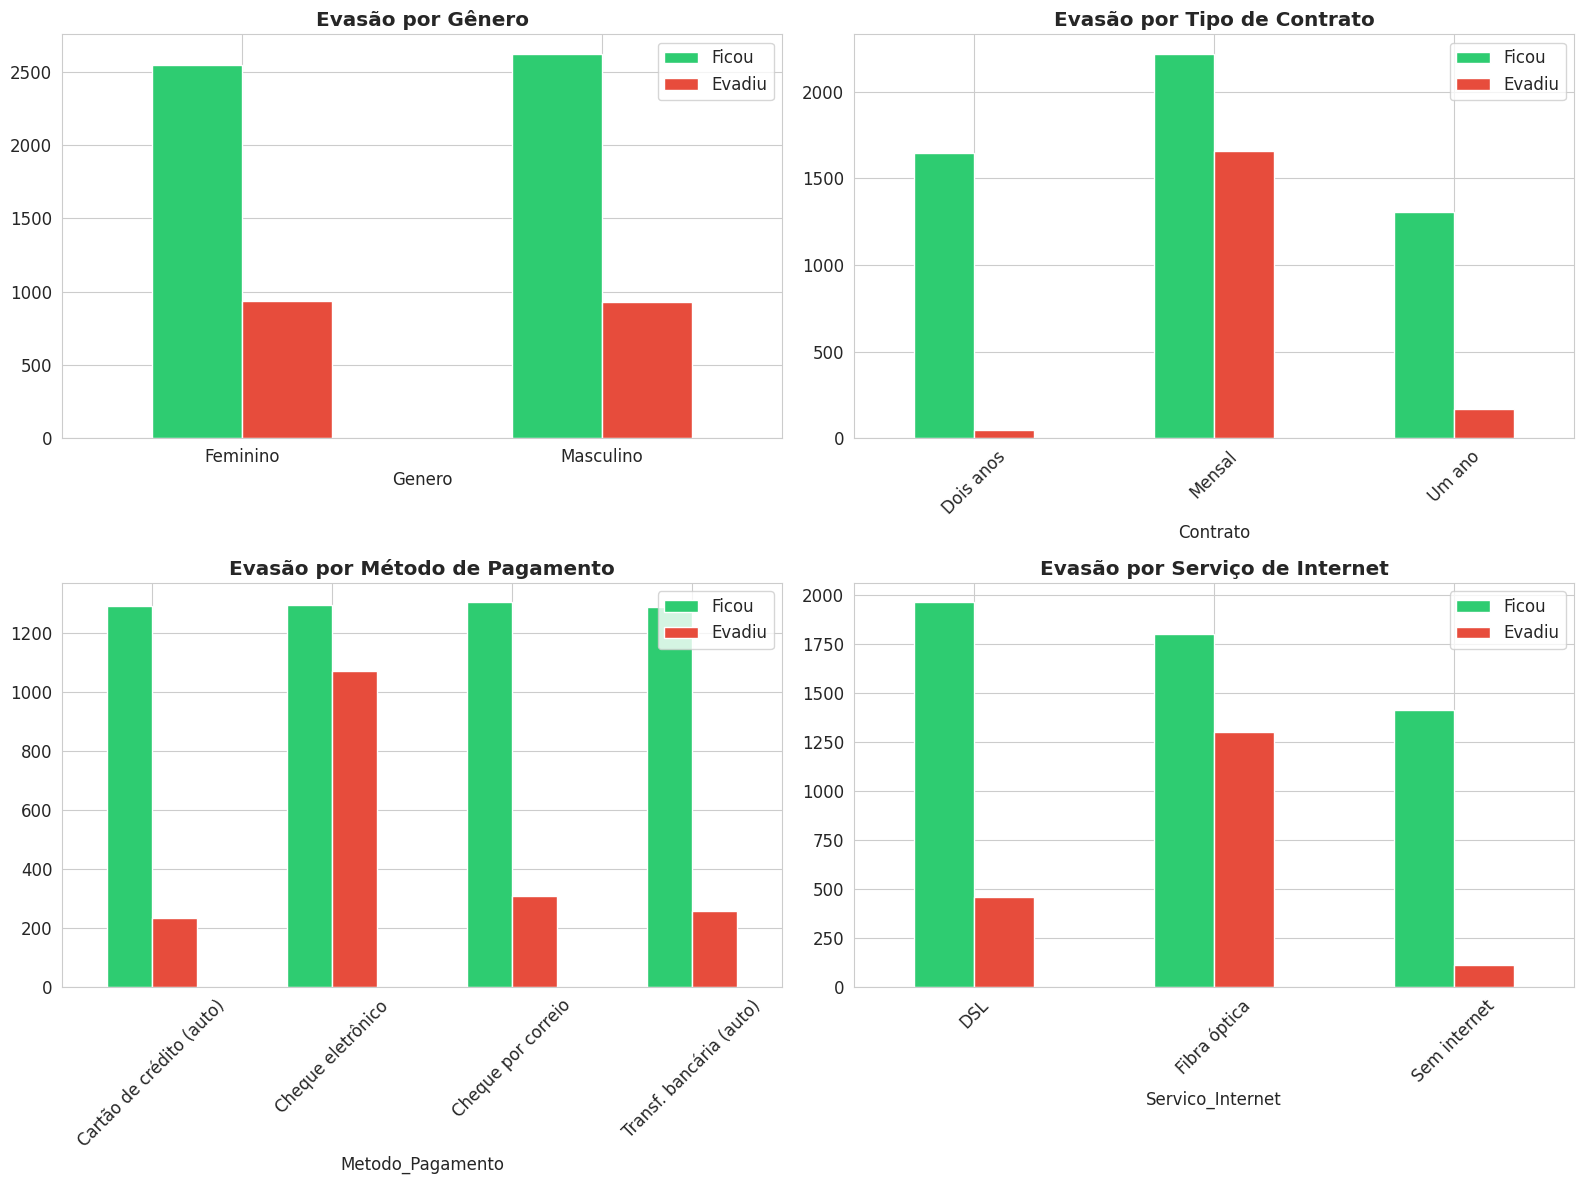

In [ ]:
# Evasão por Gênero
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Evasão por Gênero
pd.crosstab(df['Genero'], df['Evasao']).plot(kind='bar', ax=axes[0,0], color=cores)
axes[0,0].set_title('Evasão por Gênero', fontweight='bold')
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)
axes[0,0].legend(['Ficou', 'Evadiu'])

# 2. Evasão por Tipo de Contrato
pd.crosstab(df['Contrato'], df['Evasao']).plot(kind='bar', ax=axes[0,1], color=cores)
axes[0,1].set_title('Evasão por Tipo de Contrato', fontweight='bold')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45)
axes[0,1].legend(['Ficou', 'Evadiu'])

# 3. Evasão por Método de Pagamento
pd.crosstab(df['Metodo_Pagamento'], df['Evasao']).plot(kind='bar', ax=axes[1,0], color=cores)
axes[1,0].set_title('Evasão por Método de Pagamento', fontweight='bold')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45)
axes[1,0].legend(['Ficou', 'Evadiu'])

# 4. Evasão por Serviço de Internet
pd.crosstab(df['Servico_Internet'], df['Evasao']).plot(kind='bar', ax=axes[1,1], color=cores)
axes[1,1].set_title('Evasão por Serviço de Internet', fontweight='bold')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45)
axes[1,1].legend(['Ficou', 'Evadiu'])

plt.tight_layout()
plt.show()

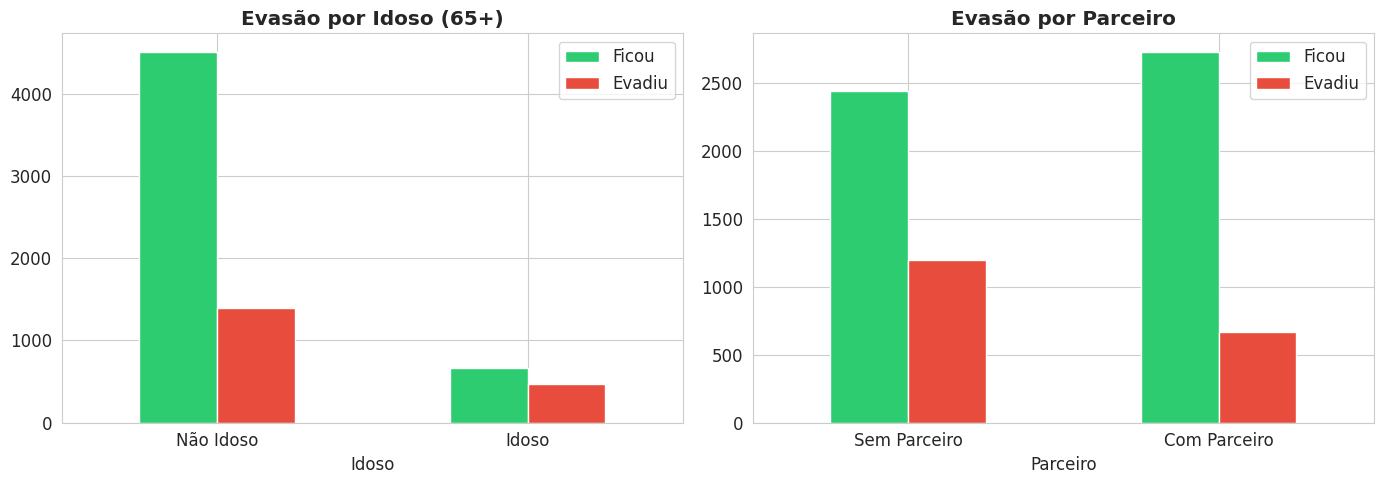

In [ ]:
# Evasão por Idoso e Parceiro
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evasão por Idoso
pd.crosstab(df['Idoso'], df['Evasao']).plot(kind='bar', ax=axes[0], color=cores)
axes[0].set_title('Evasão por Idoso (65+)', fontweight='bold')
axes[0].set_xticklabels(['Não Idoso', 'Idoso'], rotation=0)
axes[0].legend(['Ficou', 'Evadiu'])

# Evasão por Parceiro
pd.crosstab(df['Parceiro'], df['Evasao']).plot(kind='bar', ax=axes[1], color=cores)
axes[1].set_title('Evasão por Parceiro', fontweight='bold')
axes[1].set_xticklabels(['Sem Parceiro', 'Com Parceiro'], rotation=0)
axes[1].legend(['Ficou', 'Evadiu'])

plt.tight_layout()
plt.show()

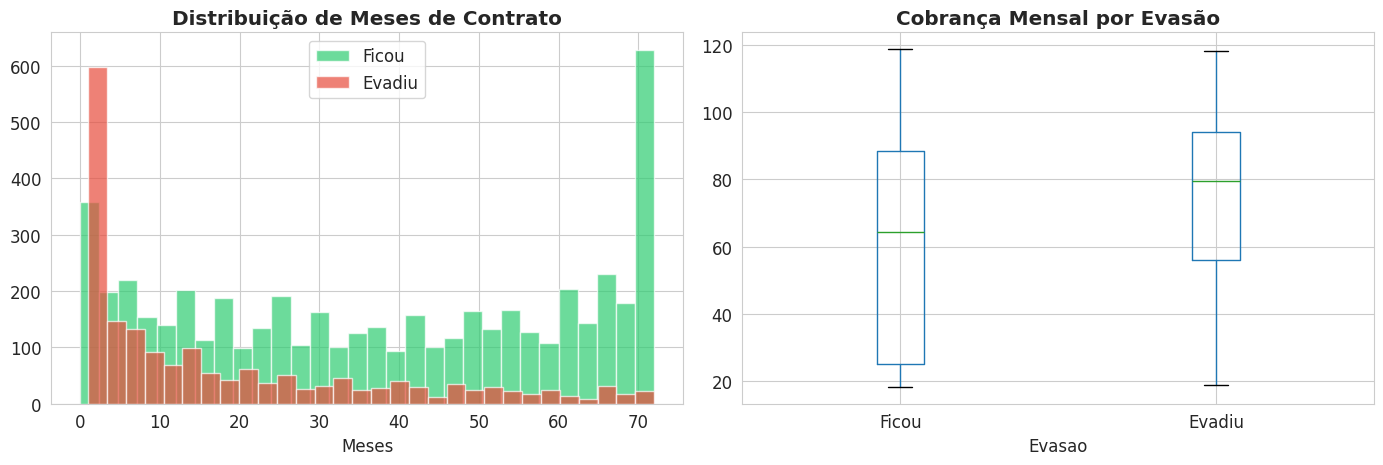

In [ ]:
# Distribuição de Meses de Contrato por Evasão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
df[df['Evasao'] == 0]['Meses_Contrato'].hist(bins=30, alpha=0.7, ax=axes[0], color='#2ecc71', label='Ficou')
df[df['Evasao'] == 1]['Meses_Contrato'].hist(bins=30, alpha=0.7, ax=axes[0], color='#e74c3c', label='Evadiu')
axes[0].set_title('Distribuição de Meses de Contrato', fontweight='bold')
axes[0].set_xlabel('Meses')
axes[0].legend()

# Boxplot
df.boxplot(column='Cobr_Mensal', by='Evasao', ax=axes[1])
axes[1].set_title('Cobrança Mensal por Evasão', fontweight='bold')
axes[1].set_xticklabels(['Ficou', 'Evadiu'])
plt.suptitle('')

plt.tight_layout()
plt.show()

## 3.4 Análise de Correlação entre Variáveis (Extra)

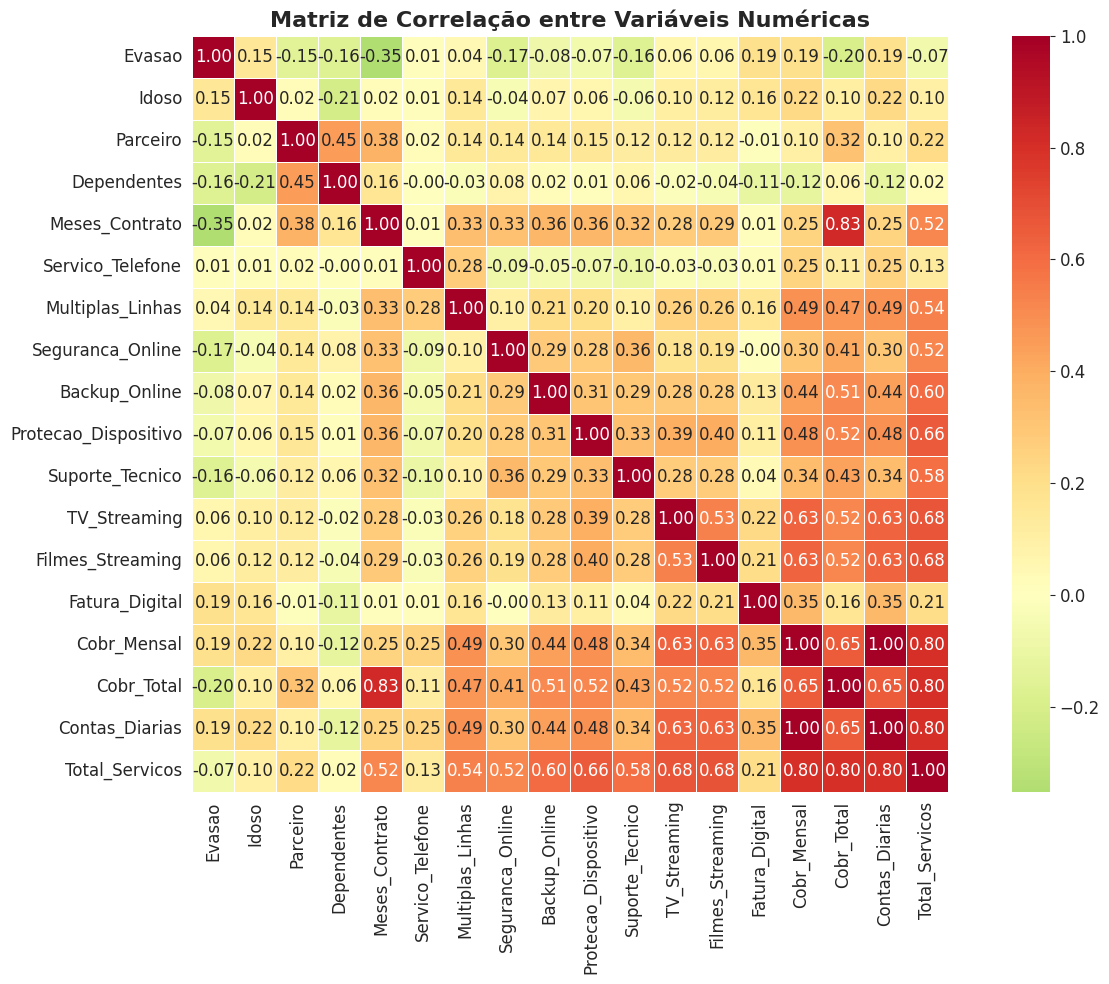

In [ ]:
# Matriz de correlação
colunas_numericas = df.select_dtypes(include=[np.number]).columns
correlacao = df[colunas_numericas].corr()

# Heatmap da correlação
plt.figure(figsize=(14, 10))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

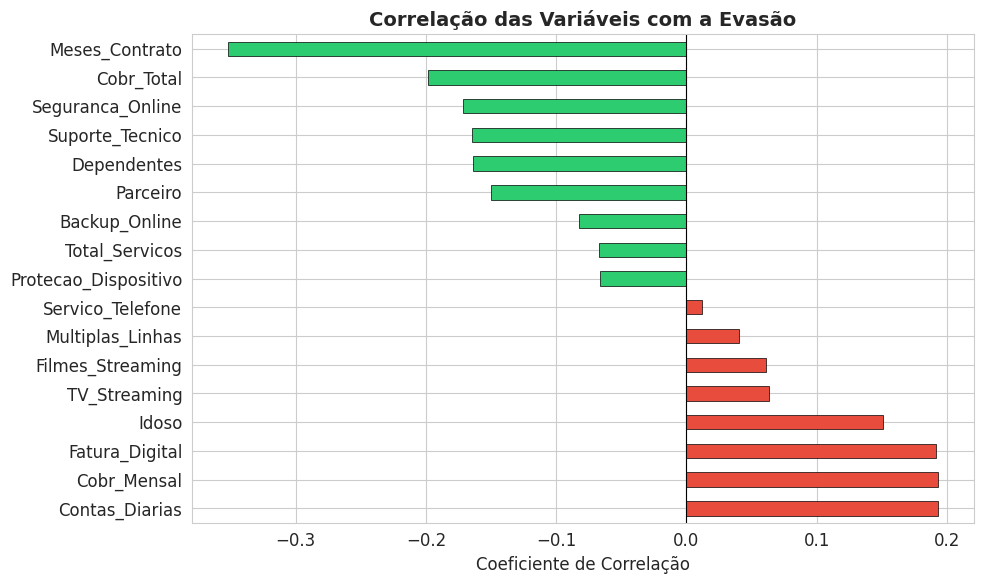


=== Top 5 variáveis mais correlacionadas com Evasão ===
Contas_Diarias    0.193412
Cobr_Mensal       0.193356
Fatura_Digital    0.191825
Idoso             0.150889
TV_Streaming      0.063228
Name: Evasao, dtype: float64


In [ ]:
# Correlação com a variável Evasão (ordenada)
correlacao_evasao = correlacao['Evasao'].drop('Evasao').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
cores_corr = ['#e74c3c' if x > 0 else '#2ecc71' for x in correlacao_evasao.values]
correlacao_evasao.plot(kind='barh', color=cores_corr, edgecolor='black', linewidth=0.5)
plt.title('Correlação das Variáveis com a Evasão', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlação')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\n=== Top 5 variáveis mais correlacionadas com Evasão ===')
print(correlacao_evasao.head())

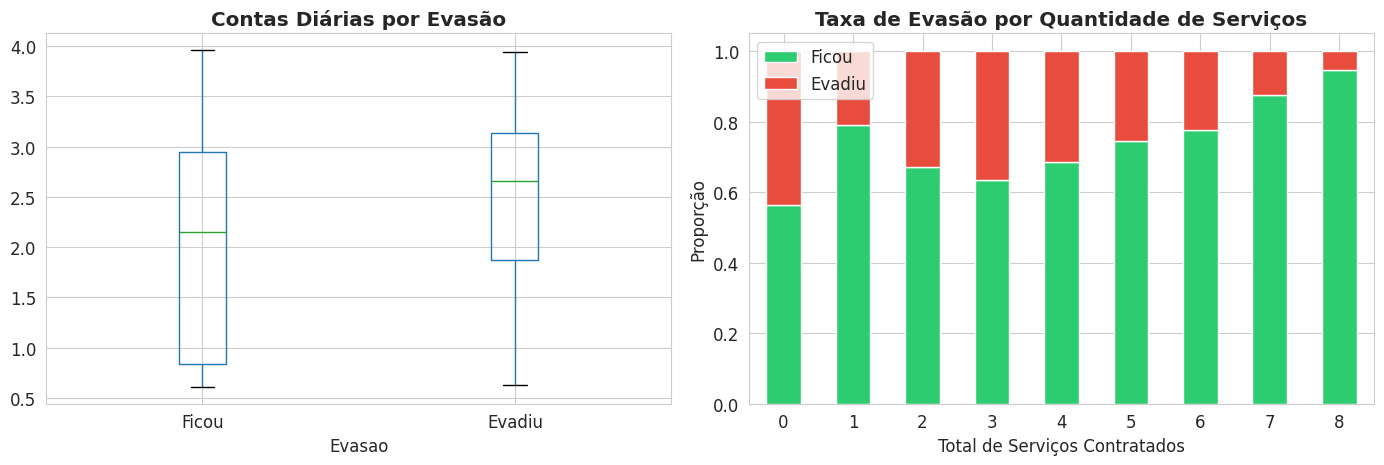

In [ ]:
# Relação entre Contas Diárias e Evasão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df.boxplot(column='Contas_Diarias', by='Evasao', ax=axes[0])
axes[0].set_title('Contas Diárias por Evasão', fontweight='bold')
axes[0].set_xticklabels(['Ficou', 'Evadiu'])
plt.suptitle('')

# Relação Total de Serviços vs Evasão
pd.crosstab(df['Total_Servicos'], df['Evasao'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1], color=cores)
axes[1].set_title('Taxa de Evasão por Quantidade de Serviços', fontweight='bold')
axes[1].set_xlabel('Total de Serviços Contratados')
axes[1].set_ylabel('Proporção')
axes[1].legend(['Ficou', 'Evadiu'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

---
# 📄 4. Relatório Final

## 📌 Introdução

Este projeto teve como objetivo analisar os dados de clientes da **TelecomX** para compreender os fatores que influenciam a **evasão de clientes (Churn)**. A retenção de clientes é fundamental para a sustentabilidade financeira de empresas de telecomunicações, e entender os padrões de evasão permite tomar decisões estratégicas mais assertivas.

O trabalho seguiu o processo de **ETL (Extração, Transformação e Carga)**, desde a importação dos dados brutos em formato JSON até a geração de insights através de análises exploratórias.

## 🧹 Limpeza e Tratamento de Dados

As seguintes etapas foram realizadas:

1. **Extração**: Dados importados de uma API REST no formato JSON e convertidos para DataFrame do Pandas usando `json_normalize`.

2. **Tratamento de inconsistências**:
   - Conversão da coluna `Cobr_Total` de texto para numérico
   - Preenchimento de valores nulos com 0
   - Verificação e remoção de duplicados

3. **Criação de novas colunas**:
   - `Contas_Diarias`: valor diário baseado na cobrança mensal
   - `Total_Servicos`: soma dos serviços contratados pelo cliente

4. **Padronização**:
   - Conversão de valores "Yes"/"No" para 1/0
   - Tradução de categorias e nomes de colunas para português
   - Renomeação de colunas para um padrão mais legível

## 📊 Análise Exploratória - Principais Achados

### Perfil da Evasão:
- A taxa de evasão observada no dataset é significativa, indicando a necessidade de ações de retenção.
- Clientes que evadem tendem a ter **menos meses de contrato** (menor tenure), sugerindo que os primeiros meses são críticos.

### Fatores de Risco:
- **Contrato mensal**: Clientes com contratos mensais têm taxas de evasão muito maiores que aqueles com contratos anuais ou bianuais.
- **Fibra óptica**: Clientes com serviço de fibra óptica apresentam maior evasão, possivelmente relacionado ao custo mais alto.
- **Cheque eletrônico**: Método de pagamento associado a maior evasão.
- **Fatura digital**: Clientes com fatura digital tendem a ter maior evasão.
- **Cobranças altas**: Clientes com valores mensais mais altos têm maior tendência à evasão.

### Fatores de Proteção:
- **Contratos longos** (1 ou 2 anos) estão associados a menor evasão.
- **Serviços adicionais** como suporte técnico e segurança online ajudam na retenção.
- **Mais serviços contratados** = menor probabilidade de evasão (maior custo de troca).

## 💡 Conclusões e Recomendações

### Recomendações Estratégicas:

1. **Programa de Retenção nos Primeiros Meses**: Criar ações de engajamento nos primeiros 6-12 meses, período crítico de evasão.

2. **Incentivar Contratos Longos**: Oferecer descontos e benefícios para clientes que migrarem de contratos mensais para anuais ou bianuais.

3. **Revisar Preços da Fibra Óptica**: Avaliar a competitividade dos preços deste serviço, dado a alta evasão associada.

4. **Pacotes de Serviços**: Incentivar a contratação de múltiplos serviços (bundles), pois clientes com mais serviços tendem a ficar.

5. **Atenção ao Método de Pagamento**: Investigar o motivo pelo qual clientes com cheque eletrônico evadem mais e incentivar migração para débito automático.

6. **Suporte Proativo para Idosos**: Clientes idosos apresentam maior evasão — oferecer atendimento personalizado pode ajudar.

7. **Monitoramento Contínuo**: Implementar dashboards de acompanhamento de métricas de churn para identificar tendências rapidamente.

